# VARIATIONAL AUTOENCODER

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [19]:
batch_size = 128

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Total training images:", len(train_dataset))

Total training images: 60000


# VAE MODEL

In [28]:
class VAE(nn.Module):

    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    # Encoder
    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    # Reparameterization Trick
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    # Decoder
    def decode(self, z):
        h = torch.relu(self.fc3(z))
        output = torch.sigmoid(self.fc4(h))
        return output

    # Forward Pass (THIS FIXES YOUR ERROR)
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z)
        return reconstructed, mu, logvar

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model Initialized")

Model Initialized


In [30]:
def loss_function(reconstructed, x, mu, logvar):

    reconstruction_loss = nn.functional.binary_cross_entropy(
        reconstructed,
        x,
        reduction='sum'
    )

    kl_divergence = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return reconstruction_loss + kl_divergence, reconstruction_loss, kl_divergence

# TRAINING LOOP

In [35]:
epochs = 20

recon_losses = []
kl_losses = []

for epoch in range(epochs):

    model.train()

    total_recon = 0
    total_kl = 0

    for data, _ in train_loader:

        data = data.view(-1,784).to(device)

        optimizer.zero_grad()

        reconstructed, mu, logvar = model(data)

        loss, recon_loss, kl_loss = loss_function(
            reconstructed,
            data,
            mu,
            logvar
        )

        loss.backward()

        optimizer.step()

        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    avg_recon = total_recon / len(train_loader.dataset)
    avg_kl = total_kl / len(train_loader.dataset)

    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print("Epoch:", epoch+1)
    print("Reconstruction Loss:", avg_recon)
    print("KL Divergence:", avg_kl)
    print("------------------------")

Epoch: 1
Reconstruction Loss: 146.18781484375
KL Divergence: 5.885443954467774
------------------------
Epoch: 2
Reconstruction Loss: 145.65990953776043
KL Divergence: 5.904772188313802
------------------------
Epoch: 3
Reconstruction Loss: 145.1763382486979
KL Divergence: 5.954525428263346
------------------------
Epoch: 4
Reconstruction Loss: 144.7036275716146
KL Divergence: 5.9649842224121095
------------------------
Epoch: 5
Reconstruction Loss: 144.318661328125
KL Divergence: 5.9789239725748695
------------------------
Epoch: 6
Reconstruction Loss: 143.8938565266927
KL Divergence: 6.004814409383138
------------------------
Epoch: 7
Reconstruction Loss: 143.5850750813802
KL Divergence: 6.04002424214681
------------------------
Epoch: 8
Reconstruction Loss: 143.25354677734376
KL Divergence: 6.057523807779948
------------------------
Epoch: 9
Reconstruction Loss: 142.97154886067707
KL Divergence: 6.0674662587483725
------------------------
Epoch: 10
Reconstruction Loss: 142.691397265

# LOSS VISUALIZATION

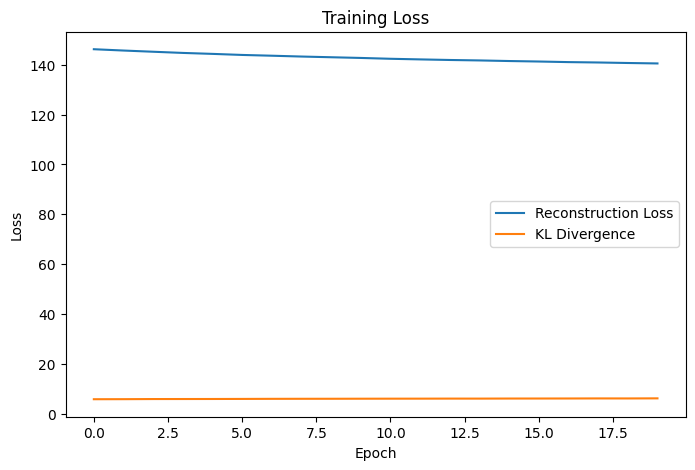

In [36]:
plt.figure(figsize=(8,5))

plt.plot(recon_losses, label="Reconstruction Loss")
plt.plot(kl_losses, label="KL Divergence")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.show()

# RECONSTRUCTION VISUALIZATION

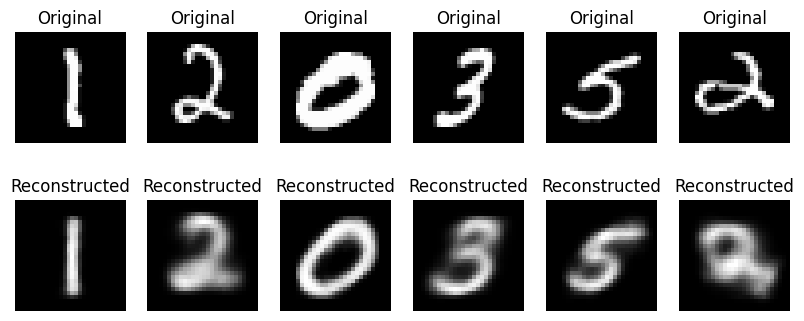

In [37]:
model.eval()

data, _ = next(iter(train_loader))

data = data.view(-1,784).to(device)

reconstructed, _, _ = model(data)

data = data.view(-1,28,28).cpu().detach()
reconstructed = reconstructed.view(-1,28,28).cpu().detach()

plt.figure(figsize=(10,4))

for i in range(6):

    plt.subplot(2,6,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,6,i+7)
    plt.imshow(reconstructed[i], cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()

# LATEN SPACE VISUALIZATION

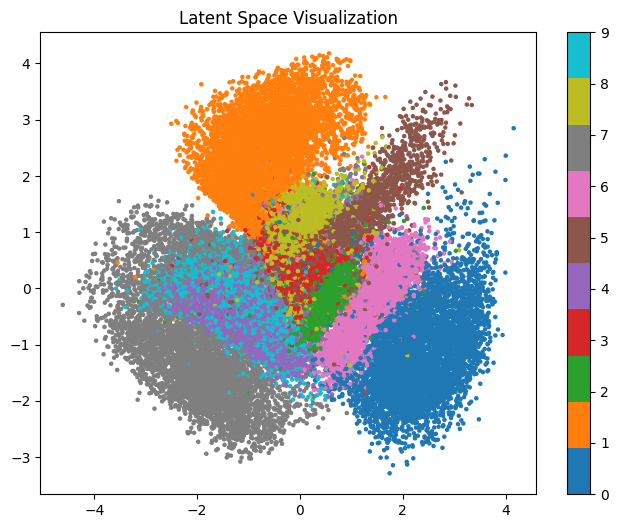

In [38]:
latent_vectors = []
labels = []

model.eval()

with torch.no_grad():

    for data, target in train_loader:

        data = data.view(-1,784).to(device)

        mu, _ = model.encode(data)

        latent_vectors.append(mu.cpu().numpy())
        labels.append(target.numpy())

latent_vectors = np.concatenate(latent_vectors)
labels = np.concatenate(labels)

plt.figure(figsize=(8,6))

plt.scatter(
    latent_vectors[:,0],
    latent_vectors[:,1],
    c=labels,
    cmap='tab10',
    s=5
)

plt.colorbar()

plt.title("Latent Space Visualization")

plt.show()

# INTERPRETATION

The encoder maps input images into a probabilistic latent space defined by mean and variance.

The reparameterization trick enables efficient training through backpropagation.

The decoder reconstructs images from latent vectors, producing outputs similar to the original inputs.

The training results and visualizations confirm that the model captures important features of handwritten digits.